In [299]:
%pip install torch torchvision torchaudio
import netCDF4 as nc
import numpy as np 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [300]:
ds = nc.Dataset("CSEM_Europe.nc")
print(list(ds.variables.keys()))   # see what's inside

['latitude', 'longitude', 'depth', 'vsv', 'vsh']


In [343]:
lat   = ds.variables['latitude'][:]
lon   = ds.variables['longitude'][:]
depth = ds.variables['depth'][:]
vsv   = ds.variables['vsv'][:]  
vsh   = ds.variables['vsh'][:]    

# Liminting to Norway 
lat_mask = (lat >= 30) & (lat <= 45)
lon_mask = (lon >= 10) & (lon <= 40)
dep_mask = depth <= 300   # upper mantle

# Fix a depth profile 
iz = np.argmin(np.abs(depth - 100.0))

# depth 
vsv_iz = vsv[iz]   
vsh_iz = vsh[iz]

# fining the lat and lon idex
lat_idx = np.where(lat_mask)[0]
lon_idx = np.where(lon_mask)[0]

# then index lat and lon
vsv_2d = np.ma.filled(vsv_iz[np.ix_(lat_idx, lon_idx)], np.nan)
vsh_2d = np.ma.filled(vsh_iz[np.ix_(lat_idx, lon_idx)], np.nan)

# Voigt average to ombinine vsv and vsh to one isotropic Vs 
vs_2d = np.sqrt((2 * vsv_2d**2 + vsh_2d**2) / 3.0)

# slowness = 1/Vs
s_true = 1.0 / vs_2d   # shape is  (n_depth, n_lon)




In [342]:
# validating the the Vs velocity 

print(f"Vs range: {vs_2d.min():.2f} - {vs_2d.max():.2f} km/s")
print(f"Depth range: {depth[dep_mask].min()} - {depth[dep_mask].max()} km")
print(f"Geometry Shape: {vs_2d.shape}")

Vs range: 3.91 - 5.12 km/s
Depth range: 0.0 - 100.0 km
Geometry Shape: (31, 61)


In [ ]:
# Fixing the shape geometry => 20x 20 by Interpolating: 

from scipy.interpolate import RegularGridInterpolator

lat_sub = lat[lat_idx]
lon_sub = lon[lon_idx]

interp = RegularGridInterpolator((lat_sub, lon_sub), vs_2d)

# Interpolate to 20x20 grid
lat_new = np.linspace(lat_sub.min(), lat_sub.max(), 20)
lon_new = np.linspace(lon_sub.min(), lon_sub.max(), 20)

Lat, Lon = np.meshgrid(lat_new, lon_new, indexing='ij')

vs_grid = interp((Lat, Lon))     
s_true  = 1.0 / vs_grid          

print(f"s_true shape: {s_true.shape}")
print(f"s_true range: {s_true.min():.4f} - {s_true.max():.4f} s/km")



s_true shape: (20, 20)
s_true range: 0.2013 - 0.2499 s/km


IndexError: index 90 is out of bounds for axis 1 with size 61

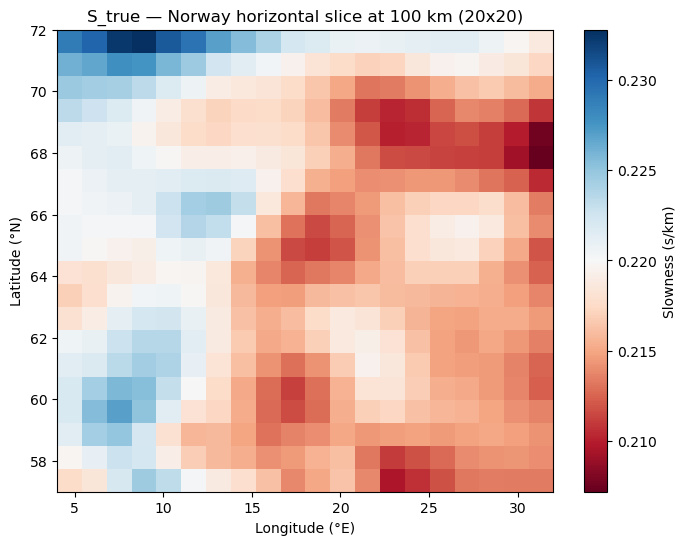

In [304]:

plt.figure(figsize=(8, 6))
plt.imshow(s_true, aspect='auto', cmap='RdBu',
           extent=[
               lon_new.min(), lon_new.max(),
                lat_new.min(), lat_new.max()
                ],
           origin='lower'
           )

plt.colorbar(label='Slowness (s/km)')
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('S_true — Norway horizontal slice at 100 km (20x20)')
plt.show()

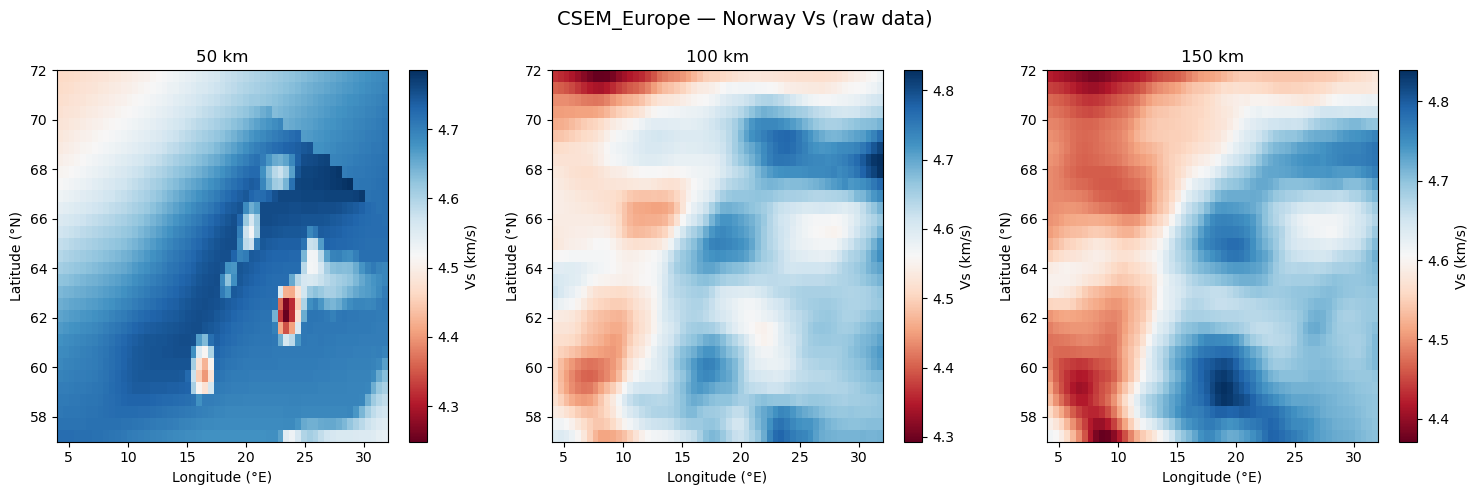

In [305]:
target_depths = [50, 100, 150]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, target_z in zip(axes, target_depths):
    iz = np.argmin(np.abs(depth - target_z))
    
    vsv_2d = np.ma.filled(vsv[iz][np.ix_(lat_idx, lon_idx)], np.nan)
    vsh_2d = np.ma.filled(vsh[iz][np.ix_(lat_idx, lon_idx)], np.nan)
    vs_2d  = np.sqrt((2 * vsv_2d**2 + vsh_2d**2) / 3.0)
    
    im = ax.imshow(vs_2d, aspect='auto', cmap='RdBu',
                   extent=[lon_new.min(), lon_new.max(),
                           lat_new.min(), lat_new.max()],
                   origin='lower')
    plt.colorbar(im, ax=ax, label='Vs (km/s)')
    ax.set_title(f'{depth[iz]:.0f} km')
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

plt.suptitle('CSEM_Europe — Norway Vs (raw data)', fontsize=14)
plt.tight_layout()
plt.show()

In [306]:
# IF TIME RUN THIS , FIND WHAT MORMOUSI MODEL TO DOWNLOAD 

# Marmousi = np.loadtxt('marmousi.txt')
# x = np.arange(0, 9192+24, 24)    # m
# z = np.arange(0, 2904+24, 24)    # m
# vp = Marmousi.reshape(len(z), len(x))
# s_true_marmousi = 1.0 / (vp / 1000.0)  # convert m/s → km/s first

In [307]:
# Block size in km (1 degree ≈ 111 km)

dx = (lon_new.max() - lon_new.min()) * 111.0 / 20
dy = (lat_new.max() - lat_new.min()) * 111.0 / 20
block_km = (dx + dy) / 2.0

print(f"block size: {block_km:.1f} km")

# Build G matrix and scale to Norway domain
Gmatrix_raw = np.loadtxt('/Users/tiffanyewa/Documents/PY/EPS 130/tomography_data/tomo_gmat.txt')
n_rays   = int(Gmatrix_raw[:, 0].max())
n_blocks = 20 * 20

G_raw = np.zeros((n_rays, n_blocks))
for ray_i, mod_j, path_len in Gmatrix_raw:
    G_raw[int(ray_i)-1, int(mod_j)-1] = path_len

G = G_raw * block_km



block size: 119.3 km


d=G⋅δs=168.7 km×0.015 s/km×13.6 blocks≈34 s

In [308]:
# Forward problem using slowness perturbations

s_mean  = s_true.ravel().mean()             # Computing the mean slowness of the true model to convert absolute slowness to perturbations
                                        
ds_true = s_true.ravel() - s_mean           # Slowness perturbations: ds = s - s_mean


# Sdd some noise
d_clean = G @ ds_true
np.random.seed(42)
d_noisy = d_clean + 0.05 * np.random.randn(n_rays)

In [309]:
print(f"G shape:       {G.shape}")
print(f"ds_true range: {ds_true.min():.4f} - {ds_true.max():.4f} s/km")
print(f"d_clean range: {d_clean.min():.3f} - {d_clean.max():.3f} s")

G shape:       (118, 400)
ds_true range: -0.0104 - 0.0152 s/km
d_clean range: -10.713 - 16.585 s


d≈144 km×0.004 s/km×13.6≈±7.8 s

In [310]:
# this is directly copies from tomography exerice

from scipy.linalg import inv

def smoothing_matrix_2d(nx, nz):
    n = nx * nz
    rows = []
    for iz in range(nz):
        for ix in range(nx):
            k = iz * nx + ix
            if ix < nx - 1:
                row = np.zeros(n)
                row[k] = -1; row[k+1] = 1
                rows.append(row)
            if iz < nz - 1:
                row = np.zeros(n)
                row[k] = -1; row[k+nx] = 1
                rows.append(row)
    return np.array(rows)

L   = smoothing_matrix_2d(20, 20)
LtL = L.T @ L
alpha = 0.1

ds_classical = np.linalg.inv(G.T @ G + alpha**2 * LtL) @ G.T @ d_noisy
s_classical  = ds_classical + s_mean   # add mean back

print(f"ds_classical range: {ds_classical.min():.4f} – {ds_classical.max():.4f} s/km")

ds_classical range: -0.0077 – 0.0140 s/km


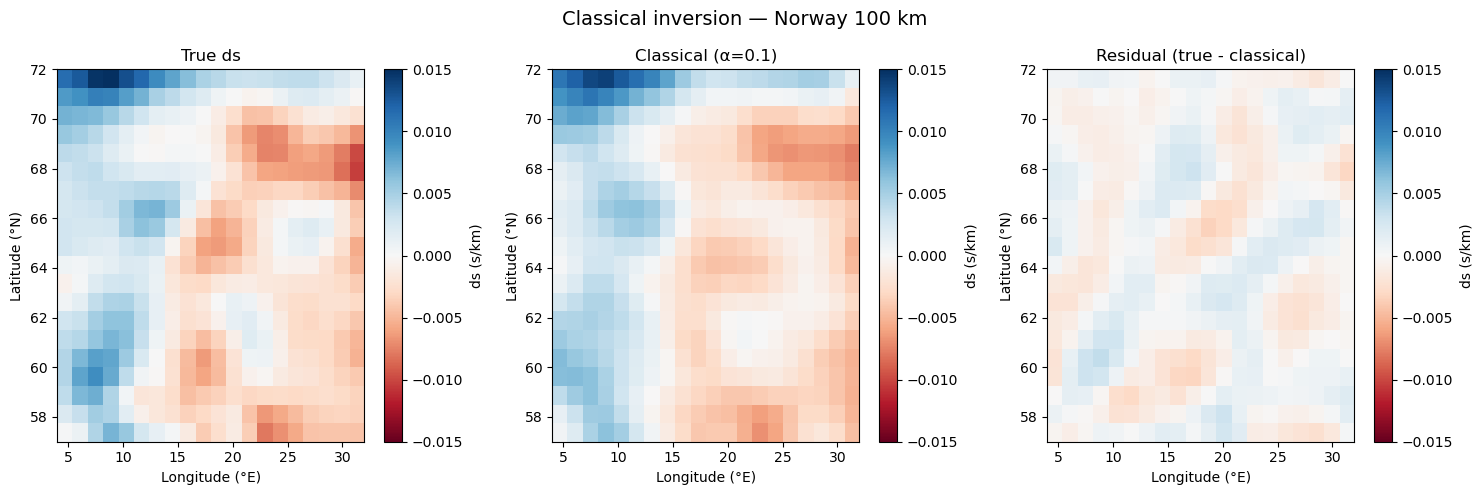

RMSE classical: 0.001368 s/km


In [311]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# True model
axes[0].imshow(ds_true.reshape(20, 20), cmap='RdBu', aspect='auto',
               extent=[lon_new.min(), lon_new.max(),
                       lat_new.min(), lat_new.max()],
               origin='lower',
               vmin=-0.015, vmax=0.015)
axes[0].set_title('True ds')

# The Recovered
im = axes[1].imshow(ds_classical.reshape(20, 20), cmap='RdBu', aspect='auto',
               extent=[lon_new.min(), lon_new.max(),
                       lat_new.min(), lat_new.max()],
               origin='lower',
               vmin=-0.015, vmax=0.015)
axes[1].set_title(f'Classical (α={alpha})')

# The diffrence
diff = ds_true - ds_classical
axes[2].imshow(diff.reshape(20, 20), cmap='RdBu', aspect='auto',
               extent=[lon_new.min(), lon_new.max(),
                       lat_new.min(), lat_new.max()],
               origin='lower',
               vmin=-0.015, vmax=0.015)
axes[2].set_title('Residual (true - classical)')

for ax in axes:
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    plt.colorbar(im, ax=ax, label='ds (s/km)')

plt.suptitle('Classical inversion — Norway 100 km', fontsize=14)
plt.tight_layout()
plt.show()

# RMSE
rmse = np.sqrt(np.mean((ds_true - ds_classical)**2))
print(f"RMSE classical: {rmse:.6f} s/km")

In [312]:
# seeing the amplitude decreases => testung to see what alpha values gived higesr 
for alpha in [0.01, 0.1, 1.0, 5.0]:
    ds_rec = np.linalg.inv(G.T @ G + alpha**2 * LtL) @ G.T @ d_noisy
    rmse = np.sqrt(np.mean((ds_true - ds_rec)**2))
    amp  = np.abs(ds_rec).max()
    print(f"alpha={alpha:5.2f}  RMSE={rmse:.6f}  max amplitude={amp:.4f} s/km")

alpha= 0.01  RMSE=0.058903  max amplitude=0.3017 s/km
alpha= 0.10  RMSE=0.001368  max amplitude=0.0140 s/km
alpha= 1.00  RMSE=0.001368  max amplitude=0.0140 s/km
alpha= 5.00  RMSE=0.001368  max amplitude=0.0140 s/km


The inversion is already rank-deficien. 
    I have 118 rays and 400 unknowns (underdetermined system). Regularization beyond α=0.1\alpha = 0.1
    α=0.1 doesn't change the solution because the smoothing already dominates.
With only 118 rays over 400 unknowns, the classical inversion is severely underdetermined. Regularization is essential but suppresses amplitude

## tomoPINN

In [313]:
# Making the neural network to represent the slowness field ds(x,y)
# Approximate slowness perturbations

class tomoPINN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(2,128), nn.Tanh(),    #The chain from input to output
            nn.Linear(128,128), nn.Tanh(),  # nn.Linear does one matric multiplixation
            nn.Linear(128,128), nn.Tanh(),  # no nn.Tanh() -> ds can any real number,
            nn.Linear(128, 1)               # Do not want to squish the output between -1 and 1.
            )
        
        # Input layer:  2 neurons ← (x, y)     
        # Hidden layer: 128 neurons
        # Hidden layer: 128 neurons
        # Hidden layer: 128 neurons
        # Output layer: 1 neuron ← ds(x,y)      

        # nn.Linear(): takes values from previous layer and combines into next layer
        # nn.Tanh(): squishes result into nonlinear shape

        # (x, y) 2 numbers in
        # nn.Linear(2, 128)  multiply by 2×128 matrix → 128 numbers
        # nn.Tanh()          squish each through tanh
        # nn.Linear(128,128) multiply by 128×128 matrix → 128 numbers
        # nn.Tanh()          squish again
        # nn.Linear(128,128) multiply by 128×128 matrix → 128 numbers
        # nn.Tanh()          squish again
        # nn.Linear(128, 1)  multiply by 128×1 matrix → 1 number
        # ds(x,y) one slowness perturbation value out


    def forward(self, x, y):
        # Input: (x, y) a point in the horizontal 2D domain
        # Output: ds -> the  predicted slowness perturbation at that point
        x = (x - 0.5) / 0.5   # normalize to [-1, 1]
        y = (y - 0.5) / 0.5
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

In [ ]:
# The loss function:
# L_data:   how well predicted travel times match observed travel times
# L_smooth: spatial smoothness penalty on ds(x,y)
# Total loss: L_data + 0.01 * L_smooth


def loss_tomo(model, x_col, y_col,
              x_data, y_data, d_obs_norm,
              G_norm, lambda_data=1.0):
    


    # L_data
    # Forward problem: d_pred = G @ ds_pred
    # Least mean squares comparing predicted travel times
    # against observed noisy travel times d_noisy
    # This is telling the network: "your slowness must explain the data"
    ds_pred = model(x_data, y_data)
    d_pred  = G_norm @ ds_pred.squeeze()
    L_data  = torch.mean((d_pred - d_obs_norm)**2)


    # L_data:
    # Forward problem: d_pred = G @ ds_pred
    # Least mean squares comparing predicted travel times
    # against observed noisy travel times d_noisy
    # This is telling the network: "your slowness must explain the data"

    ds_pred = model(x_data, y_data)
    d_pred  = G_norm @ ds_pred.squeeze()
    L_data  = torch.mean((d_pred - d_obs_norm)**2)

    # L_smooth:
    # Enforces spatial smoothness of ds(x,y) via autograd
    # Same role as alpha^2 * L^T L in classical inversion
    # NO GRID NEEDED — collocation points are scattered randomly across domain
    # PyTorch builds a computation graph as the forward pass runs.
    # Every operation involving x gets recorded in a chain:
    # x → Linear → Tanh → Linear → Tanh → ... → ds
    # When calling  autograd.grad, it walks backwards through that
    # chain applying the chain rule automatically — giving dds/dx
    # at every point simultaneously

    x_col = x_col.requires_grad_(True)
    y_col = y_col.requires_grad_(True)
    s     = model(x_col, y_col)

    ds_dx = torch.autograd.grad(s, x_col,
                grad_outputs=torch.ones_like(s),
                create_graph=True)[0]   # dds/dx
    ds_dy = torch.autograd.grad(s, y_col,
                grad_outputs=torch.ones_like(s),
                create_graph=True)[0]   # dds/dy

    # Mean squared because negative and positive gradients would otherwise cancel
    L_smooth = torch.mean(ds_dx**2 + ds_dy**2)

    # Total loss:
    # L_data + 0.01 * L_smooth (lamnda_data = 1)
    return lambda_data * L_data + 0.01 * L_smooth


In [315]:
# NO GRID NEEDED FOR PINNs
# Collocation 
# The network predicts ds at each point and smoothness is enforced there
n_col  = 2000
x_col  = torch.rand(n_col, 1, dtype=torch.float32)
y_col  = torch.rand(n_col, 1, dtype=torch.float32)

# Data points — one per block center on the 20x20 grid
# These are where the network must match G @ ds = d_obs
x_grid = torch.linspace(0, 1, 20, dtype=torch.float32)
y_grid = torch.linspace(0, 1, 20, dtype=torch.float32)
Xg, Yg = torch.meshgrid(x_grid, y_grid, indexing='ij')
x_data = Xg.reshape(-1, 1)
y_data = Yg.reshape(-1, 1)

# Convert G and observed travel times to torch tensors
#G_torch = torch.tensor(G, dtype=torch.float32)
#d_obs   = torch.tensor(d_noisy, dtype=torch.float32)

# Normalize travel times to unit scale
d_scale = d_noisy.std()
d_obs_norm = torch.tensor(d_noisy / d_scale, dtype=torch.float32)
G_norm     = torch.tensor(G / d_scale, dtype=torch.float32)

Epoch 50000  Loss: 539.018799  L_data: 176.708435
Epoch 55000  Loss: 0.141462  L_data: 0.141449
Epoch 60000  Loss: 0.166019  L_data: 0.119360
Epoch 65000  Loss: 0.073959  L_data: 0.073918
Epoch 70000  Loss: 0.056659  L_data: 0.056651
Epoch 75000  Loss: 0.039490  L_data: 0.039483


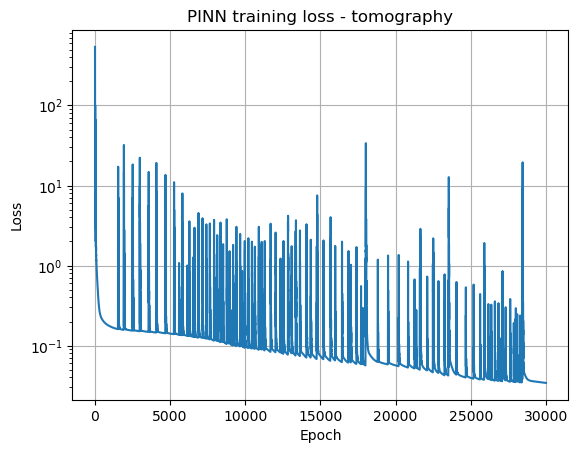

In [316]:
# Training loop -> optimizer
model_pinn = tomoPINN()
losses     = []
optimizer  = torch.optim.Adam(model_pinn.parameters(), lr=3e-4)
#scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                #optimizer, patience=2000, factor=0.5)
                # factor=0.5 → faster decay but bigger loss spikes
                # factor=0.8 → smoother loss curve

for epoch in range(50000, 80000):
    optimizer.zero_grad()
    loss = loss_tomo(model_pinn, x_col, y_col,
                     x_data, y_data, d_obs_norm, G_norm)
    loss.backward()
    optimizer.step()
    #scheduler.step(loss)
    losses.append(loss.item())

    if epoch % 5000 == 0:
        with torch.no_grad():
            ds_pred = model_pinn(x_data, y_data)
            d_pred  = G_norm @ ds_pred.squeeze()
            l_d     = torch.mean((d_pred - d_obs_norm)**2).item()
        print(f"Epoch {epoch:5d}  Loss: {loss.item():.6f}  L_data: {l_d:.6f}")

    #if epoch % 500 == 0:
       # print(f"Epoch {epoch:5d}  Loss: {loss.item():.6f}")

# Taking 10000 gradient steps/iterations. One iteration is one full pass:
# 1. Takes the current network weights
# 2. Computes the loss (data misfit + smoothness)
# 3. Computes gradients via backpropagation
# 4. Takes one small step to reduce the loss
# 5. Repeats
# Step size: lr=1e-3
# Network weights are the model, loss is what is minimized

# Tomography vs Classical inversion:
# Classical: m = (G^T G + alpha^2 L^T L)^-1 G^T d
# PINN:      PDE_residual = f(network_weights, x, y)

plt.semilogy(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PINN training loss - tomography')
plt.grid(True)
plt.show()

RMSE classical: 0.001368 s/km
RMSE PINN:      0.002125 s/km


/var/folders/qv/kltqkn2948v6nxsg6kczk5br0000gn/T/ipykernel_48779/329244394.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


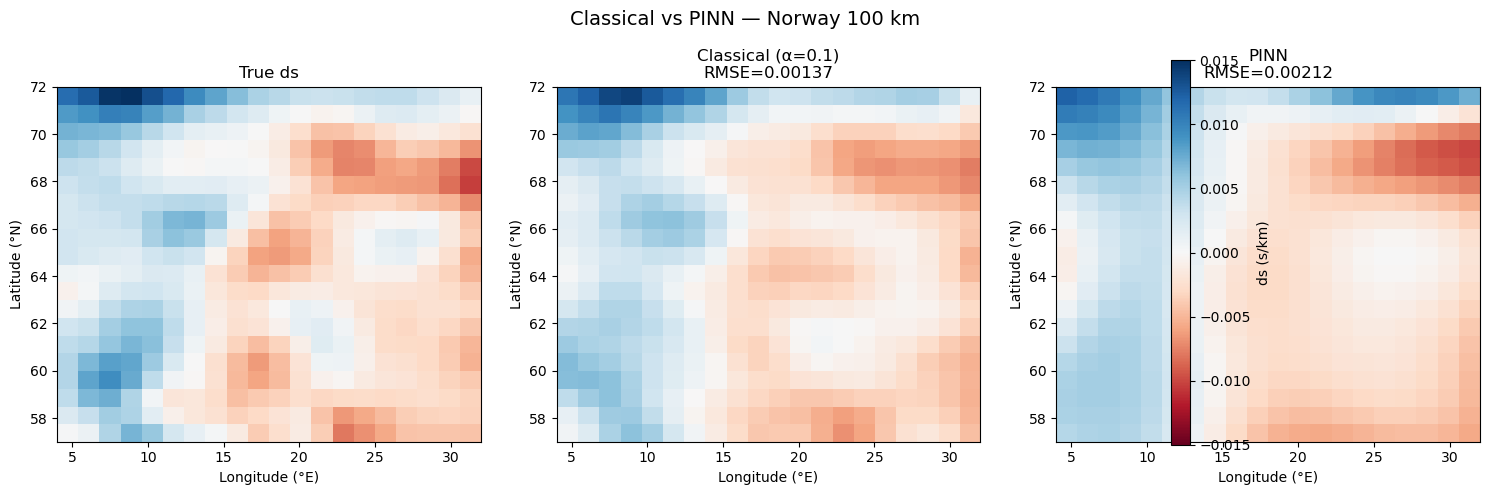

In [317]:
with torch.no_grad():
    ds_pinn = model_pinn(x_data, y_data).squeeze().numpy()

rmse_pinn      = np.sqrt(np.mean((ds_true - ds_pinn)**2))
rmse_classical = np.sqrt(np.mean((ds_true - ds_classical)**2))

print(f"RMSE classical: {rmse_classical:.6f} s/km")
print(f"RMSE PINN:      {rmse_pinn:.6f} s/km")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vmin, vmax = -0.015, 0.015
kw = dict(aspect='auto', cmap='RdBu', origin='lower', vmin=vmin, vmax=vmax,
          extent=[lon_new.min(), lon_new.max(),
                  lat_new.min(), lat_new.max()])

axes[0].imshow(ds_true.reshape(20,20), **kw)
axes[0].set_title('True ds')

axes[1].imshow(ds_classical.reshape(20,20), **kw)
axes[1].set_title(f'Classical (α=0.1)\nRMSE={rmse_classical:.5f}')

im = axes[2].imshow(ds_pinn.reshape(20,20), **kw)
axes[2].set_title(f'PINN\nRMSE={rmse_pinn:.5f}')

for ax in axes:
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

plt.colorbar(im, ax=axes, label='ds (s/km)')
plt.suptitle('Classical vs PINN — Norway 100 km', fontsize=14)
plt.tight_layout()
plt.show()

In [318]:
print(f"Max error classical: {np.abs(ds_true - ds_classical).max():.6f} s/km")
print(f"Max error PINN:      {np.abs(ds_true - ds_pinn).max():.6f} s/km")

# Where is each method worst?
err_classical = np.abs(ds_true - ds_classical).reshape(20,20)
err_pinn      = np.abs(ds_true - ds_pinn).reshape(20,20)
print(f"Classical worst block: row={np.unravel_index(err_classical.argmax(), (20,20))[0]}, col={np.unravel_index(err_classical.argmax(), (20,20))[1]}")
print(f"PINN worst block:      row={np.unravel_index(err_pinn.argmax(), (20,20))[0]}, col={np.unravel_index(err_pinn.argmax(), (20,20))[1]}")

Max error classical: 0.003715 s/km
Max error PINN:      0.006468 s/km
Classical worst block: row=4, col=3
PINN worst block:      row=19, col=17


RMSE classical: 0.001368 s/km
RMSE PINN:      0.002125 s/km


/var/folders/qv/kltqkn2948v6nxsg6kczk5br0000gn/T/ipykernel_48779/3393041353.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


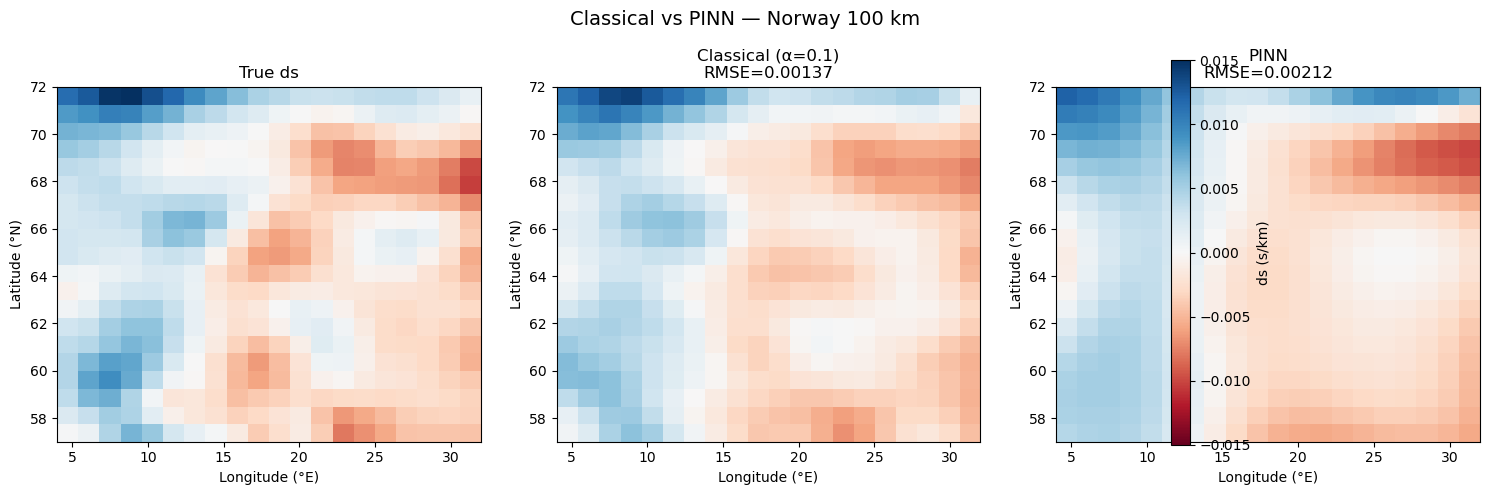

In [319]:
with torch.no_grad():
    ds_pinn = model_pinn(x_data, y_data).squeeze().numpy()

rmse_pinn      = np.sqrt(np.mean((ds_true - ds_pinn)**2))
rmse_classical = np.sqrt(np.mean((ds_true - ds_classical)**2))

print(f"RMSE classical: {rmse_classical:.6f} s/km")
print(f"RMSE PINN:      {rmse_pinn:.6f} s/km")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmin, vmax = -0.015, 0.015
kw = dict(aspect='auto', cmap='RdBu', origin='lower', vmin=vmin, vmax=vmax,
          extent=[lon_new.min(), lon_new.max(),
                  lat_new.min(), lat_new.max()])

axes[0].imshow(ds_true.reshape(20,20), **kw)
axes[0].set_title('True ds')

axes[1].imshow(ds_classical.reshape(20,20), **kw)
axes[1].set_title(f'Classical (α=0.1)\nRMSE={rmse_classical:.5f}')

im = axes[2].imshow(ds_pinn.reshape(20,20), **kw)
axes[2].set_title(f'PINN\nRMSE={rmse_pinn:.5f}')

for ax in axes:
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')

plt.colorbar(im, ax=axes, label='ds (s/km)')
plt.suptitle('Classical vs PINN — Norway 100 km', fontsize=14)
plt.tight_layout()
plt.show()